# Analisi del dataset `training.csv`
Verifichiamo che il dataset `training.csv` non contenga osservazioni palesemente errate ed effettuiamo un'analisi esplorativa del dataset rappresentando i dati in forma grafica sfruttando elementi come i boxplot, i pairplot e la matrice di correlazione.


## 1 - Verifica del dataset `training.csv`
Il dataset `training.csv` contiene un elevato numero di righe: ben 50mila. Ovviamente non possiamo analizzare manualmente ciascuna riga per capire se ci sono osservazioni palesemente errate, si automatizzano quindi grazie ad un codice python 4 tipi di controllo:

- **Valori mancanti**: Ci sono righe con celle vuote/NaN?
- **Tipi e range plausibili di valori**: Label può essere solo 0/1. TIMESTAMP/USERDID/TARGETID non devono essere negativi.
- **Righe duplicate**: La stessa osservazione è ripetuta in più righe.
- **Contraddizioni sulla chiave ACTIONID**: Verifichiamo che lo stesso ACTIONID non compaia in più righe con valori diversi delle celle. ACTIONID infatti identifica un'azione in maniera univoca.

_**Nota:** NaN = Not a Number, è il modo in cui pandas rappresenta una cella vuota/mancante in una colonna numerica. Capita quando, per qualche riga, un valore non è stato registrato (es. un sensore che non ha letto un dato, un errore di importazione, un campo lasciato vuoto nel file originale)._

In [21]:
import pandas as pd

df = pd.read_csv("../data/training.csv")

"""Valori mancanti"""
print("Numero di valori Nan per ciascuna colonna di training.csv:")
#df.isna() trasforma ciascuna cella del dataframe in un valore booleano (True se il valore è NaN, False altrimenti).
#.sum() somma i valori booleani per ciascuna colonna, restituendo il numero di valori NaN presenti in ciascuna colonna del dataframe.
print(df.isna().sum())
print("Numero totale di valori Nan in training.csv:", df.isna().sum().sum())

"""Tipi e range plausibili di valori"""
#assert condizione, messaggio è un'istruzione che verifica se la condizione è vera. Se è falsa l'esecuzione del programma si interrompe e viene stampato il messaggio di errore.
#df["LABEL"].unique() restituisce tutti i valori unici presenti nella colonna "LABEL" del dataframe df.
#set(df["LABEL"].unique()) trasfroma quei valori unici in un insieme (set) per facilitare il confronto.
#<= {0, 1} verifica se l'insieme dei valori unici della colonna "LABEL" è un sottoinsieme dell'insieme {0, 1}, cioè se tutti i valori presenti in "LABEL" sono solo 0 o 1.
assert set(df["LABEL"].unique()) <= {0, 1}, "\nLABEL contiene valori diversi da 0/1"
#df["TIMESTAMP"] >= 0 confronta ciascun valore della colonna "TIMESTAMP" con 0, restituendo una colonna di valori booleani (True se il valore è maggiore o uguale a 0, False altrimenti).
#.all() restituisce True se tutti i valori della colonna sono True, cioè se tutti i valori di "TIMESTAMP" sono maggiori o uguali a 0.
assert (df["TIMESTAMP"] >= 0).all(), "\nTimestamp negativo trovato"
#Ragionamento analogo a sopra per l'assert sottostante.
assert (df["USERID"] >= 0).all(), "\nUSERID negativo trovato"
assert (df["TARGETID"] >= 0).all(), "\nTARGETID negativo trovato"
#La riga sottostante viene eseguita solo se tutti gli assert precedenti sono stati superati.
print("\nControlli di range superati.")

"""Righe duplicate"""
#.duplicated() restituisce false se una riga non l'ha mai incontrata prima, true se l'ha già incontrata.
#con .sum() si contano le righe "di troppo" rispetto alla prima occorenza di ciascuna riga duplicata.
print("\nRighe duplicate:", df.duplicated().sum())
#eliminiamo le righe duplicate con .drop_duplicates(), che restituisce un nuovo dataframe senza le righe duplicate.
df_clean = df.drop_duplicates()

"""Contraddizioni sulla chiave ACTIONID"""
#duplicated(keep=False) marca True tutte le righe con lo stesso ACTIONID. stesso_id è quindi una colonna booleana con true per tutte le righe che hanno un ACTIONID duplicato e false per le altre.
stesso_id = df_clean["ACTIONID"].duplicated(keep=False)
#riga_identica è una colonna booleana che indica se una riga è identica a un'altra riga (True) o meno (False).
riga_identica = df_clean.duplicated(keep=False)
#troviamo quelle righe con stesso ACTIONID ma che non sono identiche tra loro. Queste righe rappresentano una contraddizione nei dati.
anomalie_id = df_clean[stesso_id & ~riga_identica].sort_values("ACTIONID")
#stampiamo il numero di osservazioni con ACTIONID duplicato ma dati contraddittori e una tabella.
print(f"\nOsservazioni con ACTIONID duplicato ma dati contraddittori: {len(anomalie_id)}")
anomalie_id
#rimuoviamo da df_clean le righe con ACTIONID uguale ma dati diversi.
df_clean = df_clean.drop(anomalie_id.index)

Numero di valori Nan per ciascuna colonna di training.csv:
ACTIONID     0
USERID       0
TARGETID     0
TIMESTAMP    0
FEATURE0     0
FEATURE1     0
FEATURE2     0
FEATURE3     0
LABEL        0
dtype: int64
Numero totale di valori Nan in training.csv: 0

Controlli di range superati.

Righe duplicate: 195

Osservazioni con ACTIONID duplicato ma dati contraddittori: 6


## 2 - Analisi esplorativa
Utilizziamo il comando `.describe()` sul dataframe df_clean per ottenere alcune statistiche descrittive di base sul dataset `training.csv`. 


In [22]:
FEATS = ["FEATURE0", "FEATURE1", "FEATURE2", "FEATURE3"]

df_clean[FEATS].describe()

,FEATURE0,FEATURE1,FEATURE2,FEATURE3
count,49799.000000,49799.000000,49799.000000,49799.000000
mean,0.002770,0.085252,-0.021543,0.000897
std,0.986119,1.130958,0.534993,0.708396
min,-0.319991,-0.435701,-0.394237,-0.067309
25%,-0.319991,-0.435701,-0.394237,-0.067309
50%,-0.319991,-0.435701,0.106784,-0.067309
75%,-0.319991,-0.435701,0.106784,-0.067309
max,25.293572,98.796794,54.718090,68.570723


## 3 - Rappresentazione in forma grafica
Analizziamo il dataset `training.csv` grazie alle seguenti tre forme di rappresentazione grafica:

- **Boxplot** (uno per ciascuna delle 4 feature): mostra mediana, quartili ed
   eventuali outlier, evidenziando come sono distribuiti i valori di ogni feature.
- **Matrice di correlazione** (tabella): riporta il coefficiente di correlazione
   tra ogni coppia di variabili (le 4 feature e LABEL), per capire quanto sono
   legate tra loro.
- **Heatmap della matrice di correlazione**: la stessa informazione della
   tabella precedente, rappresentata come mappa a colori per essere letta
   più rapidamente.

### 3.1 - Boxplot

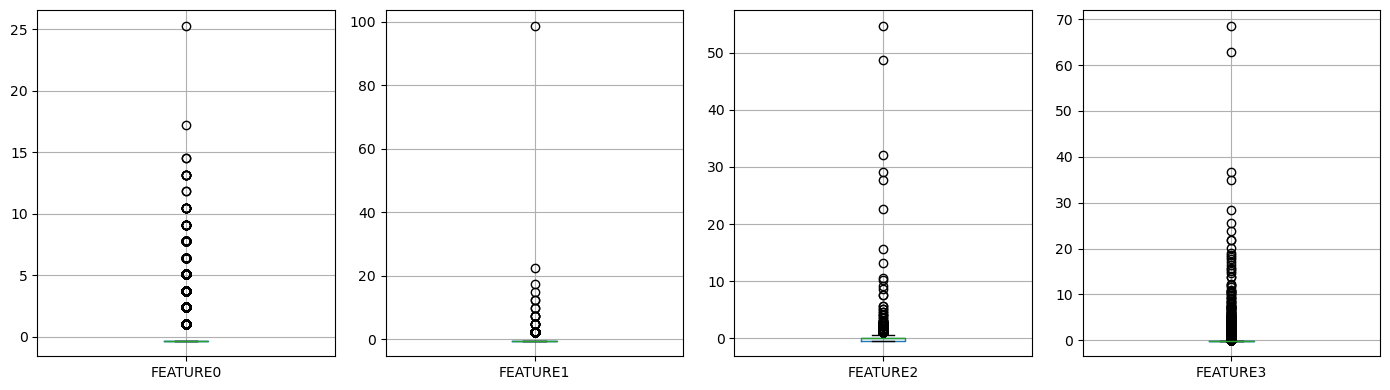

In [23]:
import matplotlib.pyplot as plt

fig, assi = plt.subplots(1, 4, figsize=(14, 4))
for ax, f in zip(assi, FEATS):
    df_clean.boxplot(column=f, ax=ax)
plt.tight_layout()
plt.show()

### 3.2 - Matrice di correlazione

In [24]:
# corr(numeric_only=True) calcola la correlazione tra tutte le coppie di colonne numeriche
correlazioni = df_clean[FEATS + ["LABEL"]].corr(numeric_only=True)
correlazioni

,FEATURE0,FEATURE1,FEATURE2,FEATURE3,LABEL
FEATURE0,1.000000,-0.150769,-0.228016,0.166399,-0.021781
FEATURE1,-0.150769,1.000000,-0.320897,-0.040051,0.063473
FEATURE2,-0.228016,-0.320897,1.000000,0.090169,-0.021814
FEATURE3,0.166399,-0.040051,0.090169,1.000000,-0.004411
LABEL,-0.021781,0.063473,-0.021814,-0.004411,1.000000


### 3.3 - Heatmap della matrice di correlazione

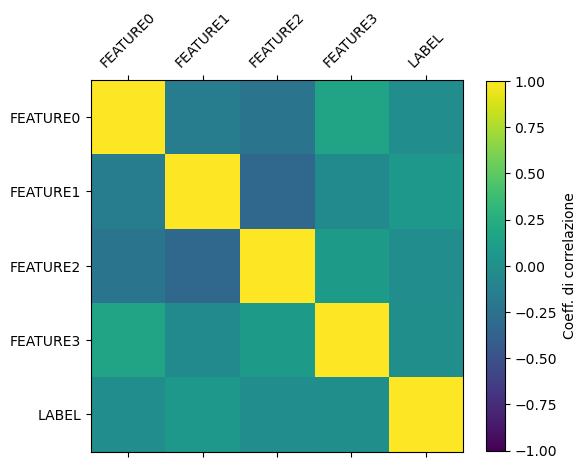

In [25]:
import numpy as np

nomi = list(correlazioni.columns)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
cax = ax.matshow(correlazioni, vmin=-1, vmax=1)
fig.colorbar(cax, shrink=0.8, label="Coeff. di correlazione")
ticks = np.arange(len(nomi))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(nomi, rotation=45)
ax.set_yticklabels(nomi)
plt.show()